# Recipe Retrieval - An Information Retrieval System
This repository defines an Information Retrieval System that can be used for recipe datasets. Given a phrase query, it will return the recipes that are more relevant in the current dataset, which contains approximately 60 thousands documents.

The recipes, in `.json` format, are pre-processed and then saved as matrixes of **TF-TDF** values, coherently with the Vector Space Model. The words are normalized and saved as an **inverted index**: each term is mapped to a posting list, which contains the document-ids of the recipes containing that term.

The inverted index is built in such a way that each term is formed by the couple `word` and `zone`. This choice was made in order to give much more importance in the retrieval to words contained in titles with respect to the ones in the ingredients and instructions parts.

For the actual retrieval, the `search engine` transforms the queries into vectors and calculates the cosine similarity with the documents vectors. The ones with larger cosine similarity are returned, ordered. The user can also provide a **relevance feedback**, that will transpose the query in the vector space closer to the relevant documents, using the Rocchio algorithm.

To make these calculations efficient, given the large number of documents and terms, the `scipy` sparce arrays were used. This made the cosine similarity calculation trivial and lowered significantly the amount of space needed to save the matrix, because of the large number of 0-values in the vectors.

A test benchmark was also developed to test our system on a subset of recipes, based on automatically generated queries. The system gave strong results and proved its robustness even with original phrase queries.

Developed by: Gabriele Pasqualini, Federico Marenco and Anna Guccione.


## Project Structure

```text
recipe-retrieval/
├── data/                       
│   ├── corpus/                 # * corpus of recipes
│   └── bin/                    # * .pkl of the inverted index and document vectors
│   └── benchmark/              # * data used for the benchmark evaluation
├── src/                        
│   ├── core/                  
│   │   ├── models.py           # Term, Posting, PostingList classes
│   │   └── index.py            # InvertedIndex class
│   ├── search/                 
│   │   ├── engine.py           # SearchEngine class
│   │   └── query.py            # retrieval logic
│   ├── utils/                  
│   │   ├── tokenizer.py        # tokenizing logic
│   │   ├── build_index.py      # index construction logic
│   │   └── corpus_parser.py    # corpus preprocessing logic
│   ├── benchmark/               
│   │   └── benchmark.py        # evaluation of the system
│   └── web/                    # integration with Flask
├── config.yaml                 # parameters
├── requirements.txt
└── README.md
```

## Steps

In [302]:
%pip install -r requirements.txt
%load_ext autoreload
%autoreload 2

import yaml

with open("config.yaml", "r") as f:
        config = yaml.safe_load(f)

Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Corpus

#### Downloading the corpus

This method scrapes from an online source the dataset that was used for the Inverted Index. It dowloads 3 json files and keeps just `RAW JSON`.

In [303]:
import requests, zipfile, io, os, shutil
RAW_JSON = "recipes_raw_nosource_fn.json"

def download_corpus(url, dir, raw_path):
    
    print("Downloading the file...")
    
    raw_dir = os.path.join(dir, "raw")
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall(raw_dir)
    for file in os.listdir(raw_dir):
        filename = os.fsdecode(file)
        if filename != RAW_JSON:
            os.remove(os.path.join(raw_dir, filename))
    
    source_file = os.path.join(raw_dir, RAW_JSON)
    
    shutil.move(str(source_file), str(raw_path))
    os.rmdir(raw_dir)
    
    print(f"Download completed: saved in {str(raw_path)}")

In [304]:
URL = "https://eightportions.com/recipes_raw.zip"
    
DIR = config["corpus"]["dir"]
RAW_PATH = config["corpus"]["raw"]

download_corpus(URL, DIR, RAW_PATH)

Download completed: saved in data/corpus/recipes_raw.json


#### Preprocessing the corpus
Converts a raw recipe dataset into a clean indexed corpus.
Skips recipes with missing title, ingredients, or instructions. If update=True, merges new recipes into an existing corpus file instead of rebuilding from scratch.

In [305]:
import json

def create_recipe_corpus(source_path, destination_path, update=False):

    with open(source_path, "r") as source_file:
        data = json.load(source_file)

    # If updating, start from the existing corpus so previous entries are preserved
    if update:
        with open(destination_path, "r") as corpus_file:
            recipe_corpus = json.load(corpus_file)
    else:
        recipe_corpus = {}

    doc_id = 0
    for index in data:
        recipe_json = data[index]

        # Skip incomplete records — all three fields are required for indexing
        if not (recipe_json
                and recipe_json.get('ingredients')
                and recipe_json.get('instructions')
                and recipe_json.get('title')):
            continue

        recipe_corpus[doc_id] = {
            'title':        recipe_json.get('title'),
            'ingredients':  "\n".join(recipe_json.get('ingredients')),
            'instructions': recipe_json.get('instructions')
        }
        doc_id += 1
    
    with open(destination_path, "w") as destination_file:
        json.dump(recipe_corpus, destination_file, indent=4)

In [306]:
CLEAN_PATH = config["corpus"]["clean"]

print("Pre-processing the corpus...")
create_recipe_corpus(RAW_PATH, CLEAN_PATH, update=False)
print(f"Pre-processing completed. Corpus available at {CLEAN_PATH}")

with open(CLEAN_PATH, "r") as source_file:
    corpus = json.load(source_file)
    
print("First recipe:", corpus[str(0)])

Pre-processing the corpus...
Pre-processing completed. Corpus available at data/corpus/recipes.json
First recipe: {'title': "Grammie Hamblet's Deviled Crab", 'ingredients': '1/2 cup celery, finely chopped\n1 small green pepper finely chopped\n1/2 cup finely sliced green onions\n1/4 cup chopped parsley\n1 pound crabmeat\n1 1/4 cups coarsely crushed cracker crumbs\n1/2 teaspoon salt\n3/4 teaspoons dry mustard\nDash hot sauce\n1/4 cup heavy cream\n1/2 cup melted butter', 'instructions': 'Toss ingredients lightly and spoon into a buttered baking dish. Top with additional crushed cracker crumbs, and brush with melted butter. Bake in a preheated at 350 degrees oven for 25 to 30 minutes or until delicately browned.'}


### Index
#### Building the index
Here a subclass of the acutal Inverted Index class is built as a toy example, with an entry cap, in order to cut execution time in the jupiter notebook.

In [307]:
from src.core.index import InvertedIndex
from tqdm import tqdm
from src.core.models import Term, PostingList
from src.utils.tokenize import tokenize

# we take just a subset of all the recipes for demonstration purposes
corpus = {str(k): corpus[str(k)] for k in range(100)}

class ExampleInvertedIndex(InvertedIndex):
    
    def populate_index(self, corpus):
        
        # First pass: build posting lists for every (token, zone) pair
        for doc_id in tqdm(corpus, desc="Indexing", unit="doc"):
            for zone in self.zones:
                text = corpus[doc_id][zone]
                for token in tokenize(text):
                    term = Term(token, zone)
                    if term not in self.index:
                        self.index[term] = PostingList()
                    self.index[term].add_occurrence(doc_id)

        # Second pass: compute IDF and populate vocab + spell-checker dictionary
        for position, term in enumerate(self.index):
            posting_list = self.index[term]
            term.update_idf(len(corpus), len(posting_list))
            self.vocab[term] = position
            self.spell.create_dictionary_entry(term.word, count=1)

In [308]:
print("Building Inverted Index...")
idx = ExampleInvertedIndex(corpus, zones=config['settings']['zones'])

Building Inverted Index...


Indexing: 100%|██████████| 100/100 [00:00<00:00, 223.68doc/s]


#### Vector matrices

This method creates the matrix of the document vectors, in line with the Vector Space Model. To do that, the module sparce from scipy was used, to avoid the waste of storage.

In [309]:
from scipy.sparse import csr_array
from sklearn.preprocessing import normalize

def build_doc_vectors(inverted_index, corpus):

    number_of_terms = len(inverted_index)
    number_of_docs = len(corpus)

    vocab = inverted_index.vocab

    # for the doc vectors, we generate a sparse array to avoid wasting space with zeros entries
    # this data structure instead of saving a #docs x #terms matrix, saves the value of tf-idf and the corresponding coordinates
    rows, cols, data = [], [], []

    for term, postings in inverted_index:
        for posting in postings:
            rows.append(posting.doc_id)
            cols.append(vocab[term])
            data.append(posting.tf * term.idf)

    # generate the sparse matrix
    vectors = csr_array((data, (rows, cols)), shape=(number_of_docs, number_of_terms))
    return  normalize(vectors, norm='l2', axis=1)


In [310]:
print("Building Document Vectors...")
doc_vectors = build_doc_vectors(idx, corpus)
print("Vector matrix built.")

print(doc_vectors.shape)

first_recipe =  doc_vectors[0]
first_recipe = first_recipe.toarray().flatten()

print("\nFirst recipe vector:")
for i, idf in enumerate(first_recipe):
    if idf != 0:
        term = idx.get_term(i)
        print(f"{term} -> {idf}")

Building Document Vectors...
Vector matrix built.
(100, 2478)

First recipe vector:
additional.instructions -> 0.14092740127215714
bake.instructions -> 0.0484036956560037
baking.instructions -> 0.13435549293734625
brown.instructions -> 0.044554118977657514
brush.instructions -> 0.10970266979423969
butter.instructions -> 0.0968073913120074
butter.ingredients -> 0.051126027312468375
celery.ingredients -> 0.1183037737811415
chop.ingredients -> 0.1492447807641103
coarsely.ingredients -> 0.16715206725412948
crab.title -> 0.19565446707558226
crabmeat.ingredients -> 0.19565446707558226
cracker.instructions -> 0.19565446707558226
cracker.ingredients -> 0.21827809456659786
cream.ingredients -> 0.082003114483135
crumb.instructions -> 0.15697912042836187
crumb.ingredients -> 0.16715206725412948
crush.instructions -> 0.21827809456659786
crush.ingredients -> 0.14092740127215714
cup.ingredients -> 0.05049254507339993
dash.ingredients -> 0.21827809456659786
degree.instructions -> 0.07516230572034867


## Search engine

In [311]:
query = "spicy"

#### 

#### Creation of the query vector

In the `query_to_vector` method, the query is tokenized. This includes removing stopword, lemmatization (all steps included also in the preprocessing of the index) and additionally the spelling correction. 

In [312]:
for token in tokenize(query):
        print(token, end="")
        token = idx.correct(token)
        print(f" --> {token}")

spicy --> spicy


In [313]:
import numpy as np

def query_to_vector(query):
    weights = {"title": 0.75, "instructions": 0.25, "ingredients": 0.1}
    vocab = idx.vocab
    vector = np.zeros(len(vocab))
    for token in tokenize(query):
        token = idx.correct(token)
        for zone, weight in weights.items():
            term = Term(token, zone)
            if term in idx:
                vector[vocab[term]] += weight

    norma = np.linalg.norm(vector)
    if norma > 0:
        vector /= norma
        
    return csr_array(vector)

vector = query_to_vector(query)

#### Computing cosine similarity
Similarities are computed with dot product between the query vector and the document vectors matrix.
The 10 highest cosine similarities documents are printed

In [314]:
def search(vector, n=10, verbose=False):
    
    similarities = vector.dot(doc_vectors.T).toarray().flatten()
    top_n_indices = np.argsort(similarities)[::-1][:n]

    for doc_id in top_n_indices:
        title = corpus.get(str(doc_id), {}).get('title')
        if verbose: print(f"ID: {doc_id} | Sim: {similarities[doc_id]:.4f} | Recipe: {title}")
        
    return top_n_indices

In [315]:
top_n_indices = search(vector, verbose=True)

ID: 69 | Sim: 0.1911 | Recipe: Grilled Calamari on Mizuna Greens
ID: 35 | Sim: 0.0489 | Recipe: Pizza with Fried Calamari (from Al Forno)
ID: 99 | Sim: 0.0000 | Recipe: Wild Rice Pancakes
ID: 26 | Sim: 0.0000 | Recipe: Roasted Potatoes with Dill
ID: 27 | Sim: 0.0000 | Recipe: Beet Salad
ID: 28 | Sim: 0.0000 | Recipe: Tuna Provencale
ID: 29 | Sim: 0.0000 | Recipe: Georgian Short Ribs of Beef with Beets, Leeks and Horseradish Mashed Potatoes
ID: 30 | Sim: 0.0000 | Recipe: Prime Porterhouse Steak
ID: 31 | Sim: 0.0000 | Recipe: Baked Eggs with Green Chiles and Capers
ID: 32 | Sim: 0.0000 | Recipe: Remoulade


#### Relevance feedback with Rocchio algorithm

In [316]:
def rocchio_algorithm(query_vec, relevant_vecs, non_relevant_vecs, alpha=1.0, beta=0.75, gamma=0.15):

    relevant_centroid = (
        sum(relevant_vecs) / relevant_vecs.shape[0] 
        if relevant_vecs.shape[0] > 0 else 0)
    non_relevant_centroid = (
        sum(non_relevant_vecs) / non_relevant_vecs.shape[0]
        if non_relevant_vecs.shape[0] > 0 else 0
    )

    return (alpha * query_vec) + (beta * relevant_centroid) - (gamma * non_relevant_centroid)

In [317]:
# Given the query and the set of user choices for relevant recipes a new query vector is computed with Rocchio
def apply_relevance_feedback(vec_q, relevant_ids, all_top_ids):
        relevant_vecs = doc_vectors[relevant_ids]
        non_relevant_ids = [idx for idx in all_top_ids if idx not in relevant_ids]
        non_relevant_vecs = doc_vectors[non_relevant_ids]
        return rocchio_algorithm(vec_q, relevant_vecs, non_relevant_vecs)

Recomputing the cosine similarity with the new query corrected with relevance feedback

In [318]:
relevant_ids = [69, 35] # relevant ids choosen by the user

corrected_vector = apply_relevance_feedback(vector, relevant_ids, top_n_indices)

top_n_indices = search(corrected_vector, verbose=True)

ID: 69 | Sim: 0.6054 | Recipe: Grilled Calamari on Mizuna Greens
ID: 35 | Sim: 0.4628 | Recipe: Pizza with Fried Calamari (from Al Forno)
ID: 45 | Sim: 0.1804 | Recipe: Soppressata Pizzas
ID: 92 | Sim: 0.1404 | Recipe: Veggie 'n' Buffalo Chicken Pizza
ID: 83 | Sim: 0.1099 | Recipe: Coconut Cream Pie with Chocolate-Painted Crust
ID: 21 | Sim: 0.0823 | Recipe: Happy Holly's Banana Cream Pie
ID: 15 | Sim: 0.0778 | Recipe: Strawberry Rhubarb Pie
ID: 64 | Sim: 0.0726 | Recipe: Pulled Pork Sandwiches
ID: 89 | Sim: 0.0715 | Recipe: Homemade Biscuits
ID: 65 | Sim: 0.0684 | Recipe: Grilled Baby Lamb T-Bone


## Benchmark

A set of automatically generated queries was used to test our system.

In [319]:
with open(config['benchmark']['evaluation_set'], "r") as f:
        test_cases = json.load(f)

### Average Precision
Computes Average Precision for a single query.

In [320]:
def calculate_ap(retrieved_ids, relevant_ids):
    
    actual_relevant_found = 0
    precision_sum = 0

    for i, res_id in enumerate(retrieved_ids, 1):
        if res_id in relevant_ids:
            actual_relevant_found += 1
            # Precision at rank i: how many relevant docs in the top-i results
            precision_sum += (actual_relevant_found / i)

    # Avoid division by zero if no relevant documents exist for this query
    if not relevant_ids:
        return 0

    # Normalise by total number of relevant documents, not just those retrieved
    return precision_sum / len(relevant_ids)

### Testing on multiple queries

In [321]:
precisions = []
recalls = []
aps = []

for case in test_cases:
        vector_query = query_to_vector(case["query"])
        relevant_ids = [str(rid) for rid in case["relevant_ids"]]

        # Retrieve top-5 results from the search engine
        retrieved_indices = search(vector_query, n=5)
        retrieved_ids = [str(rid) for rid in retrieved_indices]

        # Count how many retrieved documents are actually relevant
        hits = len([rid for rid in retrieved_ids if rid in relevant_ids])

        # Precision: relevant hits / total retrieved
        precisions.append(hits / len(retrieved_ids) if retrieved_ids else 0)

        # Recall: relevant hits / total relevant documents for this query
        recalls.append(hits / len(relevant_ids) if relevant_ids else 0)

        # Average Precision for this query
        aps.append(calculate_ap(retrieved_ids, relevant_ids))

### MAP

Now the MAP can be calculated.

In [322]:
print("MAP: ", np.mean(aps))

MAP:  0.6687256410256411


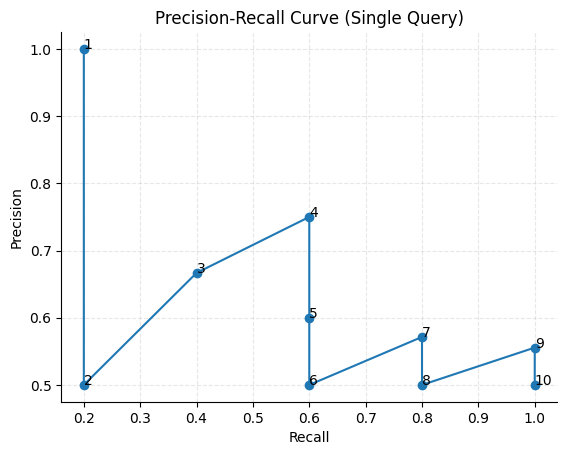

In [333]:
import matplotlib.pyplot as plt

# Esempio: lista binaria delle rilevanze nella ranked list (1 = rilevante, 0 = non rilevante)
relevance = [1, 0, 1, 1, 0, 0, 1, 0, 1, 0]

# Numero totale di documenti rilevanti nella collezione (ground truth)
total_relevant = sum(relevance)

precisions = []
recalls = []

relevant_so_far = 0

for i, rel in enumerate(relevance, start=1):
    if rel == 1:
        relevant_so_far += 1
    
    precision = relevant_so_far / i
    recall = relevant_so_far / total_relevant if total_relevant > 0 else 0
    
    precisions.append(precision)
    recalls.append(recall)

# Plot
plt.figure()
plt.plot(recalls, precisions, marker='o')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Single Query)')
plt.grid(True)

# Annota ogni punto con l'indice del documento
for i, (r, p) in enumerate(zip(recalls, precisions), start=1):
    plt.text(r, p, str(i))

plt.show()